### Homework 1 - Advanced Microeconomics

### Problem 2.1

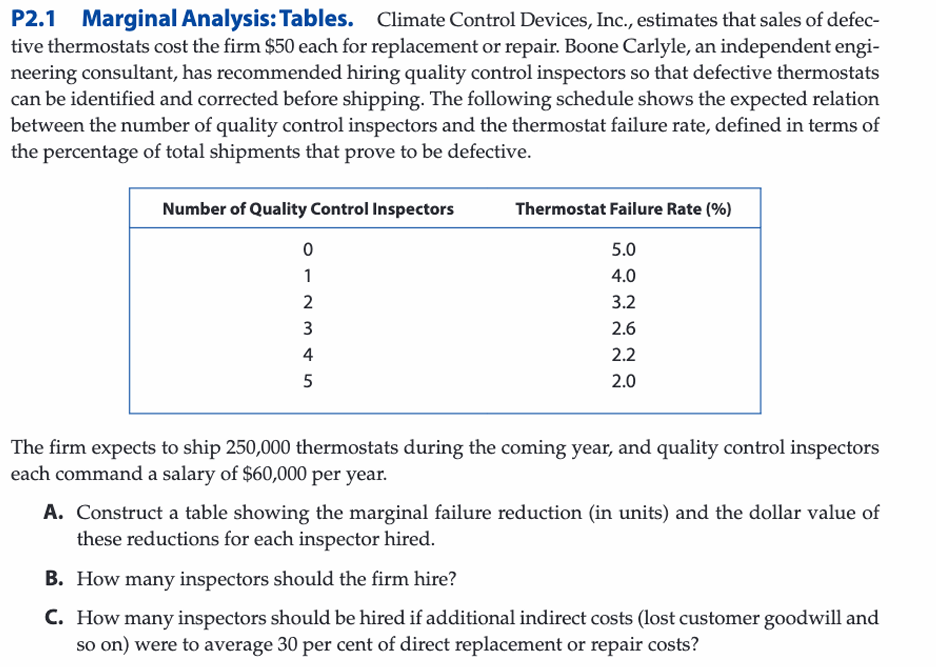

In [1]:
from pathlib import Path
from IPython.display import Image

image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.1.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)

In [7]:
import pandas as pd 

# Given information 
shipments = 250000
replacement_cost = 50 
inspector_salary = 60000 
indirect_cost_rate = 0.30 

# Number of inspectors 
inspectors  = [0, 1, 2, 3, 4, 5] 

# Failure rate corresponding to each number of inspectors 
failure_rates = [5.0, 4.0, 3.2, 2.6, 2.2, 2.0] 

# Create a DataFrame to organize the data 
df = pd.DataFrame({
    'Inspectors': inspectors,
    'Failure Rate (%)': failure_rates
})

df

,Inspectors,Failure Rate (%)
0,0,5.0
1,1,4.0
2,2,3.2
3,3,2.6
4,4,2.2
5,5,2.0


### a. Marginal Failure Rate

In [8]:
df["Marginal Failure Reduction (%)"] = df["Failure Rate (%)"].diff().fillna(0) * -1 
print(df)

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)
0           0               5.0                            -0.0
1           1               4.0                             1.0
2           2               3.2                             0.8
3           3               2.6                             0.6
4           4               2.2                             0.4
5           5               2.0                             0.2


 The first row is -0.0 because there is no previous row to compare with, so the marginal failure reduction is calculated as 0.

### Calculate defective thermostats avoided  

For example the firm ships 250,000 thermostats, the first inspector reduces failure by 1%

- 250,000 * 0.01 = 2,500 defective thermostats avoided 

In [10]:
df["Defective Thermostats Avoided (units)"] = shipments * df["Marginal Failure Reduction (%)"] / 100
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  
0                                   -0.0  
1                                 2500.0  
2                                 2000.0  
3                                 1500.0  
4                                 1000.0  
5                                  500.0  


### Calculate marginal direct savings

In [ ]:
df["Marginal Direct Savings ($)"] = (df["Defective Thermostats Avoided (units)"] * replacement_cost)   
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  
0                                   -0.0                         -0.0  
1                                 2500.0                     125000.0  
2                                 2000.0                     100000.0  
3                                 1500.0                      75000.0  
4                                 1000.0                      50000.0  
5                                  500.0                      25000.0  


### Calculate marginal net benefits

In [12]:
df["Marginal Net Benefits ($)"] = df["Marginal Direct Savings ($)"] - inspector_salary
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  \
0                                   -0.0                         -0.0   
1                                 2500.0                     125000.0   
2                                 2000.0                     100000.0   
3                                 1500.0                      75000.0   
4                                 1000.0                      50000.0   
5                                  500.0                      25000.0   

   Marginal Net Be

### Automatically Determine Part B

In [13]:
positive_benefits  = df[df["Marginal Net Benefits ($)"] > 0] 

number_of_inspectors_B = len(positive_benefits) 

print(
    f"Part B: The firm should hire "
    f"{number_of_inspectors_B} inspectors."
)

Part B: The firm should hire 3 inspectors.


### Part C: Include 30% indirect costs 

- Total_cost = Direct_cost * (1 + 0.3) 

In [15]:
df["Savings Including Indirect Costs ($)"] = df["Marginal Direct Savings ($)"] * (1 + indirect_cost_rate)
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  \
0                                   -0.0                         -0.0   
1                                 2500.0                     125000.0   
2                                 2000.0                     100000.0   
3                                 1500.0                      75000.0   
4                                 1000.0                      50000.0   
5                                  500.0                      25000.0   

   Marginal Net Be

### Calculate net benefits including indirect costs

In [16]:
# calculate net benefits including indirect costs 
df["Net Benefits Including Indirect Costs ($)"] = df["Savings Including Indirect Costs ($)"] - inspector_salary
print(df) 

   Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  \
0           0               5.0                            -0.0   
1           1               4.0                             1.0   
2           2               3.2                             0.8   
3           3               2.6                             0.6   
4           4               2.2                             0.4   
5           5               2.0                             0.2   

   Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  \
0                                   -0.0                         -0.0   
1                                 2500.0                     125000.0   
2                                 2000.0                     100000.0   
3                                 1500.0                      75000.0   
4                                 1000.0                      50000.0   
5                                  500.0                      25000.0   

   Marginal Net Be

In [17]:
positive_benefits_C = df[
    df["Net Benefits Including Indirect Costs ($)"] > 0
]

number_of_inspectors_C = len(positive_benefits_C)

print(
    f"Part C: The firm should hire "
    f"{number_of_inspectors_C} inspectors."
)

Part C: The firm should hire 4 inspectors.


In [18]:
df.columns.tolist()

['Inspectors',
 'Failure Rate (%)',
 'Marginal Failure Reduction (%)',
 'Defective Thermostats Avoided (units)',
 'Marginal Direct Savings ($)',
 'Marginal Net Benefits ($)',
 'Savings Including Indirect Costs ($)',
 'Net Benefits Including Indirect Costs ($)']

In [19]:
# Final cleaner Table 
display_columns = [
    "Inspectors",
    "Failure Rate (%)",
    "Marginal Failure Reduction (%)",
    "Defective Thermostats Avoided (units)",
    "Marginal Direct Savings ($)",
    "Marginal Net Benefits ($)",
    "Savings Including Indirect Costs ($)",
    "Net Benefits Including Indirect Costs ($)"
]
result = df[display_columns].copy() 
print(result.to_string(index=False)) 

 Inspectors  Failure Rate (%)  Marginal Failure Reduction (%)  Defective Thermostats Avoided (units)  Marginal Direct Savings ($)  Marginal Net Benefits ($)  Savings Including Indirect Costs ($)  Net Benefits Including Indirect Costs ($)
          0               5.0                            -0.0                                   -0.0                         -0.0                   -60000.0                                  -0.0                                   -60000.0
          1               4.0                             1.0                                 2500.0                     125000.0                    65000.0                              162500.0                                   102500.0
          2               3.2                             0.8                                 2000.0                     100000.0                    40000.0                              130000.0                                    70000.0
          3               2.6                   

In [23]:
df["Decision_without_Indirect_Costs"] = df["Marginal Net Benefits ($)"].apply(lambda x: "Hire" if x > 0 else "Do Not Hire")

df["Decision_with_Indirect_Costs"] = df["Net Benefits Including Indirect Costs ($)"].apply(lambda x: "Hire" if x > 0 else "Do Not Hire")


print(
    df[[
        "Inspectors",
        "Marginal Net Benefits ($)",
        "Net Benefits Including Indirect Costs ($)",
        "Decision_without_Indirect_Costs",
        "Decision_with_Indirect_Costs"
    ]].to_string(index=False)
)

 Inspectors  Marginal Net Benefits ($)  Net Benefits Including Indirect Costs ($) Decision_without_Indirect_Costs Decision_with_Indirect_Costs
          0                   -60000.0                                   -60000.0                     Do Not Hire                  Do Not Hire
          1                    65000.0                                   102500.0                            Hire                         Hire
          2                    40000.0                                    70000.0                            Hire                         Hire
          3                    15000.0                                    37500.0                            Hire                         Hire
          4                   -10000.0                                     5000.0                     Do Not Hire                         Hire
          5                   -35000.0                                   -27500.0                     Do Not Hire                  Do Not Hire

### Problem 2.2 Incremental Analysis

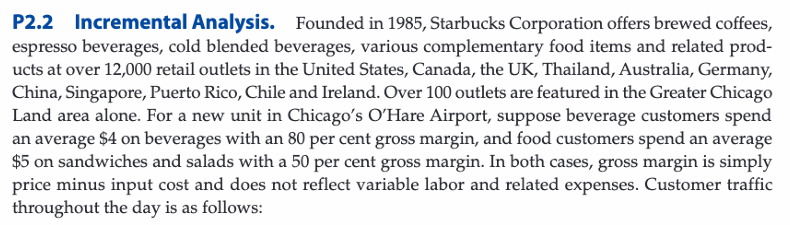

In [24]:
from pathlib import Path
from IPython.display import Image

image_relative_path = Path('Finance/Adv_Micro_Economics/sample_exercises/problem2.2.png')
search_directories = [Path.cwd(), *Path.cwd().parents]
path = next(
    directory / image_relative_path
    for directory in search_directories
    if (directory / image_relative_path).is_file()
)
Image(filename=str(path), width=800, height=800)